In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import cleaning as cln

### CẤU HÌNH HIỂN THỊ TOÀN CỤC

In [14]:
sns.set_theme(style="darkgrid", palette="muted", font_scale=1.05)
plt.rcParams.update({
    "figure.facecolor": "#F8F9FA",
    "axes.facecolor":   "#F0F0F5",
    "figure.dpi":       130,
})
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

RAW_PATH    = "cellphones_raw.csv"
ANTUTU_PATH = "antutu_socket.csv"

### CHƯƠNG 1: TÌM HIỂU DỮ LIỆU 

1.1 Đọc dữ liệu 

In [15]:

df_raw    = pd.read_csv(RAW_PATH)
df_antutu = pd.read_csv(ANTUTU_PATH)

print(f"\n[raw]    Shape : {df_raw.shape}  →  {df_raw.shape[0]} sản phẩm, {df_raw.shape[1]} thuộc tính")
print(f"[antutu] Shape : {df_antutu.shape}  →  {df_antutu.shape[0]} chipsets\n")

print("─── df_raw.info() ───")
df_raw.info(verbose=True, show_counts=True)




[raw]    Shape : (966, 50)  →  966 sản phẩm, 50 thuộc tính
[antutu] Shape : (233, 6)  →  233 chipsets

─── df_raw.info() ───
<class 'pandas.DataFrame'>
RangeIndex: 966 entries, 0 to 965
Data columns (total 50 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Unnamed                 966 non-null    int64
 1    0                      966 non-null    int64
 2   Name                    966 non-null    str  
 3   Price                   333 non-null    str  
 4   Link                    966 non-null    str  
 5   Kích thước màn hình     873 non-null    str  
 6   Công nghệ màn hình      814 non-null    str  
 7   Camera sau              855 non-null    str  
 8   Camera trước            823 non-null    str  
 9   Chipset                 857 non-null    str  
 10  Công nghệ NFC           762 non-null    str  
 11  Bộ nhớ trong            915 non-null    str  
 12  Thẻ SIM                 696 non-null    str  
 13  Hệ điều hà

In [16]:
df_antutu.info()

<class 'pandas.DataFrame'>
RangeIndex: 233 entries, 0 to 232
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Link          233 non-null    str  
 1   Chipset       233 non-null    str  
 2   Antutu_11     233 non-null    int64
 3   Clock         233 non-null    str  
 4   GPU           233 non-null    str  
 5   Architecture  233 non-null    str  
dtypes: int64(1), str(5)
memory usage: 11.1 KB


In [17]:
df_antutu.head()

,Link,Chipset,Antutu_11,Clock,GPU,Architecture
0,/en/soc/qualcomm-snapdragon-8-elite-2,Snapdragon 8 Elite Gen 5,3932243,4610 MHz,Adreno 840,2x 4.61 GHz – Oryon Gen 3 Prime | 6x 3.63 GHz ...
1,/en/soc/apple-a19-pro,A19 Pro,2606807,4260 MHz,Apple A19 Pro GPU,2x 4.26 GHz – Everest | 4x 2.6 GHz – Sawtooth
2,/en/soc/mediatek-dimensity-9500,Dimensity 9500,3508681,4210 MHz,Mali-G1 Ultra MP12,1x 4.21 GHz – C1-Ultra | 3x 3.5 GHz – C1-Premi...
3,/en/soc/samsung-exynos-2600,Exynos 2600,3145925,3800 MHz,Samsung Xclipse 960,1x 3.8 GHz – C1-Ultra | 3x 3.25 GHz – C1-Pro |...
4,/en/soc/qualcomm-snapdragon-8-gen-4,Snapdragon 8 Elite (Gen 4),3336910,4320 MHz,Adreno 830,2x 4.32 GHz – Oryon (Phoenix L) | 6x 3.53 GHz ...


 1.2 Phân tích Missing Values 

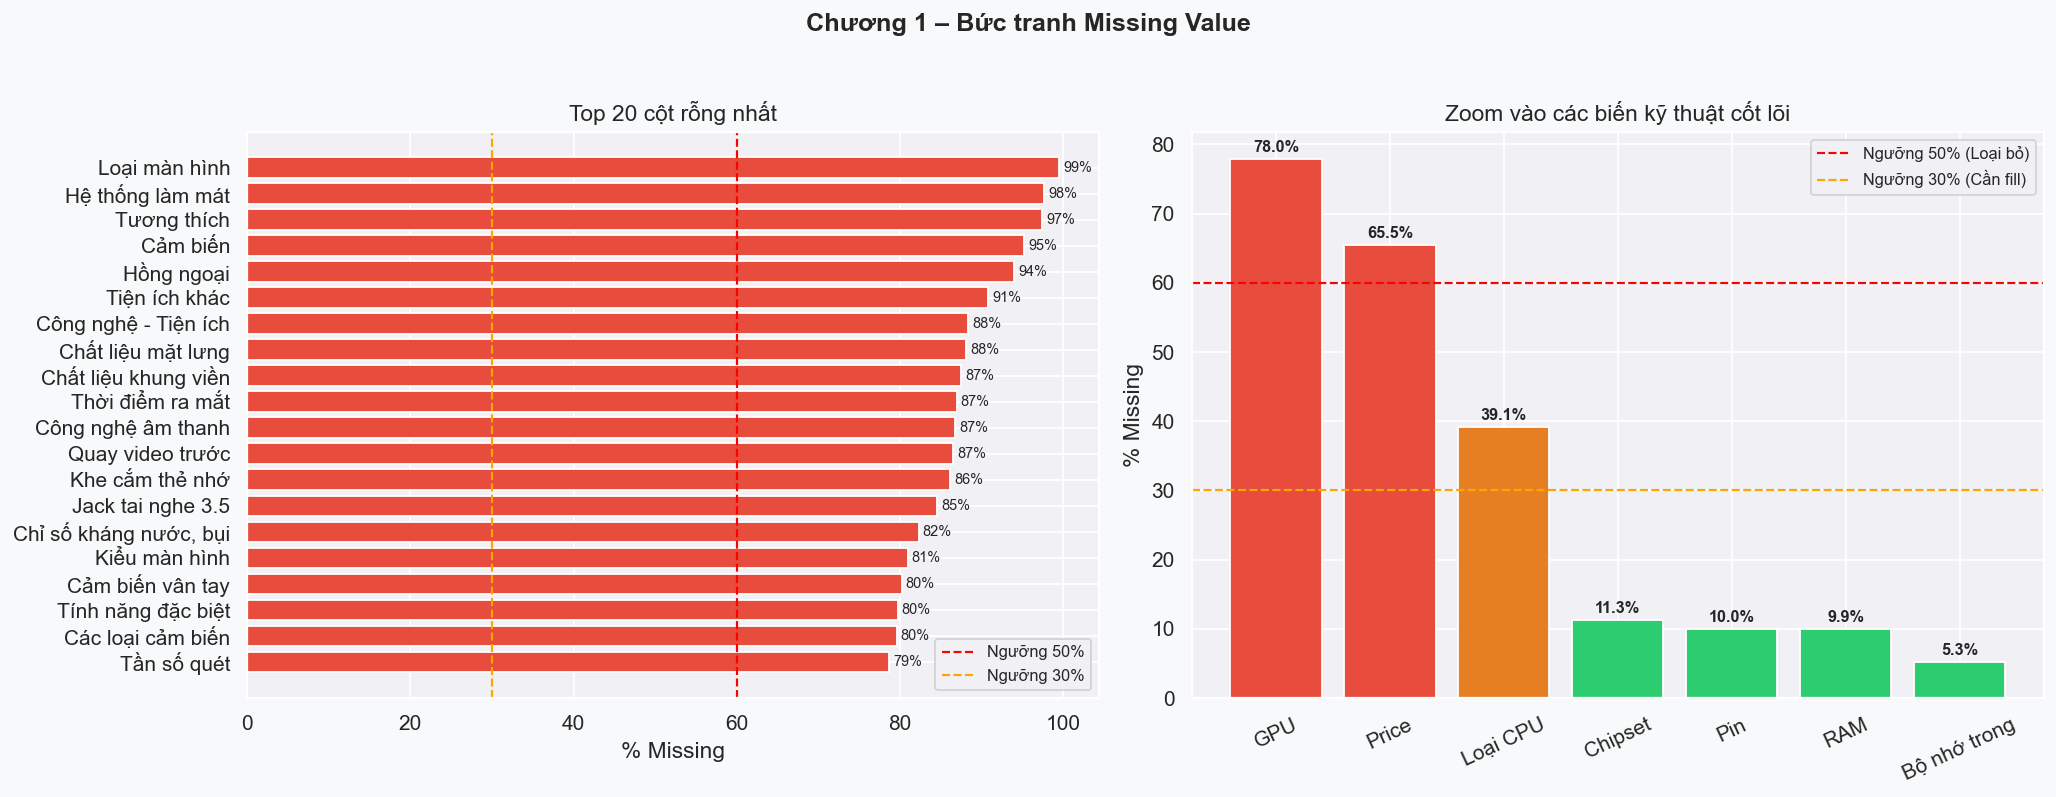

In [18]:

null_summary = (
    df_raw.isna().sum()
    .rename("null_count")
    .to_frame()
    .assign(null_pct=lambda x: x["null_count"] / len(df_raw) * 100)
    .sort_values("null_pct", ascending=False)
)

def plot_missing_values(df_raw, null_summary):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("Chương 1 – Bức tranh Missing Value",
                 fontsize=14, fontweight="bold", y=1.02)

    # Subplot trái: Top 20 cột rỗng nhất
    top20 = null_summary.head(20)
    colors = ["#E74C3C" if p > 50 else "#E67E22" if p > 30 else "#3498DB" for p in top20["null_pct"]]
    axes[0].barh(top20.index[::-1], top20["null_pct"][::-1], color=colors[::-1])
    axes[0].axvline(60, color="red",    linestyle="--", linewidth=1.2, label="Ngưỡng 50%")
    axes[0].axvline(30, color="orange", linestyle="--", linewidth=1.2, label="Ngưỡng 30%")
    axes[0].set_xlabel("% Missing")
    axes[0].set_title("Top 20 cột rỗng nhất")
    axes[0].legend(fontsize=9)
    for i, val in enumerate(top20["null_pct"][::-1]):
        axes[0].text(val + 0.5, i, f"{val:.0f}%", va="center", fontsize=8)

    # Subplot phải: Biến kỹ thuật cốt lõi
    key_cols = {
        "Price":       df_raw["Price"].isna().mean() * 100,
        "GPU":         df_raw["GPU"].isna().mean() * 100,
        "Loại CPU":    df_raw["Loại CPU"].isna().mean() * 100,
        "Chipset":     df_raw["Chipset"].isna().mean() * 100,
        "RAM":         df_raw["Dung lượng RAM"].isna().mean() * 100,
        "Pin":         df_raw["Pin"].isna().mean() * 100,
        "Bộ nhớ trong":df_raw["Bộ nhớ trong"].isna().mean() * 100,
    }
    key_df  = pd.Series(key_cols).sort_values(ascending=False)
    bar_col = ["#E74C3C" if v > 50 else "#E67E22" if v > 30 else "#2ECC71" for v in key_df]
    bars = axes[1].bar(key_df.index, key_df.values, color=bar_col, edgecolor="white")
    axes[1].axhline(60, color="red",    linestyle="--", linewidth=1.2, label="Ngưỡng 50% (Loại bỏ)")
    axes[1].axhline(30, color="orange", linestyle="--", linewidth=1.2, label="Ngưỡng 30% (Cần fill)")
    axes[1].set_ylabel("% Missing")
    axes[1].set_title("Zoom vào các biến kỹ thuật cốt lõi")
    axes[1].legend(fontsize=9)
    axes[1].tick_params(axis="x", rotation=25)
    for bar, val in zip(bars, key_df.values):
        axes[1].text(bar.get_x() + bar.get_width() / 2, val + 1, f"{val:.1f}%", ha="center", fontsize=9, fontweight="bold")
    plt.tight_layout()
    plt.show()

plot_missing_values(df_raw, null_summary)

In [19]:
gpu_pre_fill = df_raw["GPU"].notna().mean() * 100
cpu_pre_fill = df_raw['Loại CPU'].notna().mean() * 100

Loại bỏ những features có số lượng null > 50%

In [20]:
thresh_limit = 0.5 * df_raw.shape[0]

cols_to_check = [col for col in df_raw.columns if col != "Tần số quét"]

cols_to_keep = (
    df_raw[cols_to_check].dropna(thresh=thresh_limit, axis=1).columns.tolist()
)

cols_to_keep.append("Tần số quét")

df_raw = df_raw[cols_to_keep]

In [21]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 966 entries, 0 to 965
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Unnamed                966 non-null    int64
 1    0                     966 non-null    int64
 2   Name                   966 non-null    str  
 3   Link                   966 non-null    str  
 4   Kích thước màn hình    873 non-null    str  
 5   Công nghệ màn hình     814 non-null    str  
 6   Camera sau             855 non-null    str  
 7   Camera trước           823 non-null    str  
 8   Chipset                857 non-null    str  
 9   Công nghệ NFC          762 non-null    str  
 10  Bộ nhớ trong           915 non-null    str  
 11  Thẻ SIM                696 non-null    str  
 12  Hệ điều hành           762 non-null    str  
 13  Độ phân giải màn hình  659 non-null    str  
 14  Tính năng màn hình     732 non-null    str  
 15  Loại CPU               588 non-null    str  
 16  D

In [22]:
df_raw.head(5)

,Unnamed,0,Name,Link,Kích thước màn hình,Công nghệ màn hình,Camera sau,Camera trước,Chipset,Công nghệ NFC,Bộ nhớ trong,Thẻ SIM,Hệ điều hành,Độ phân giải màn hình,Tính năng màn hình,Loại CPU,Dung lượng RAM,Pin,Tần số quét
0,0,0,iPhone 17 Pro 256GB | Chính hãng,https://cellphones.com.vn/iphone-17-pro.html,6.3 inches,Super Retina XDR,Chính: 48MP khẩu độ ƒ/1.6 OIS hỗ trợ chụp 24MP...,Camera 18MP Center Stage Khẩu độ ƒ/1.9,Chip A19 Pro,Có,256 GB,Sim kép (nano-Sim và e-Sim) - Hỗ trợ 2 e-Sim,iOS 26,2622 x 1206 pixels,"Màn hình Luôn Bật, ProMotion 120Hz, HDR, True ...",CPU 6 lõi với 2 lõi hiệu năng và 4 lõi tiết ki...,NaN,NaN,120Hz
1,1,1,OPPO Find X9s 12GB 256GB,https://cellphones.com.vn/dien-thoai-oppo-find...,6.59 inches,AMOLED,Góc siêu rộng: 50MP; Góc rộng: 50MP; Telephoto...,32MP,MediaTek Dimensity 9500s,Có,256 GB,Dual nano-SIM hoặc 1 nano-SIM + 1 eSIM,ColorOS 16.0,1256 x 2760 pixels,"Tần số lấy mẫu cảm ứng 240Hz, 1.07 tỷ màu (10 ...",8 nhân,12 GB,7025 mAh,120Hz
2,2,2,Samsung Galaxy S26 Ultra 12GB 256GB,https://cellphones.com.vn/dien-thoai-samsung-g...,6.9 inches,Dynamic AMOLED 2X,Camera siêu rộng: 50MPCamera góc rộng: 200MPCa...,12MP,Snapdragon 8 Elite Gen 5 dành cho Galaxy (3nm),Có,256 GB,2 Nano-SIM + eSIM,NaN,3120 x 1440 pixels (Quad HD+),Tần số quét: 1-120HzĐộ sáng tối đa: 2600 nits,NaN,12 GB,5000 mAh,120Hz
3,3,3,iPhone 17 Pro Max 256GB | Chính hãng,https://cellphones.com.vn/iphone-17-pro-max.html,6.9 inches,Super Retina XDR,Chính: 48MP khẩu độ ƒ/1.6 OIS hỗ trợ chụp 24MP...,Camera 18MP Center Stage Khẩu độ ƒ/1.9,Chip A19 Pro,Có,256 GB,Sim kép (nano-Sim và e-Sim) - Hỗ trợ 2 e-Sim,iOS 26,2868 x 1320 pixels,"Màn hình Luôn Bật, ProMotion 120Hz, HDR, True ...",CPU 6 lõi với 2 lõi hiệu năng và 4 lõi tiết ki...,NaN,NaN,120Hz
4,4,4,Samsung Galaxy S26 12GB 256GB,https://cellphones.com.vn/dien-thoai-samsung-g...,6.3 inches,Dynamic AMOLED 2X,Camera siêu rộng: 12MPCamera góc rộng: 50MPCam...,12MP,Exynos 2600 (2nm),Có,256 GB,2 Nano-SIM + eSIM,NaN,2340 x 1080-pixel,Tần số quét: 1-120HzĐộ sáng tối đa: 2600 nits,NaN,12 GB,4300 mAh,120Hz


1.3 Thực Hiện Merge Với Antutu 


[Merge Result thực tế từ cln.add_chipset_info]
  Số dòng sau merge    : 966
  Match Antutu         : 748/966 (77.4%)
  GPU_final coverage   : 77.4%  (từ 22.0% lên 77.4%)


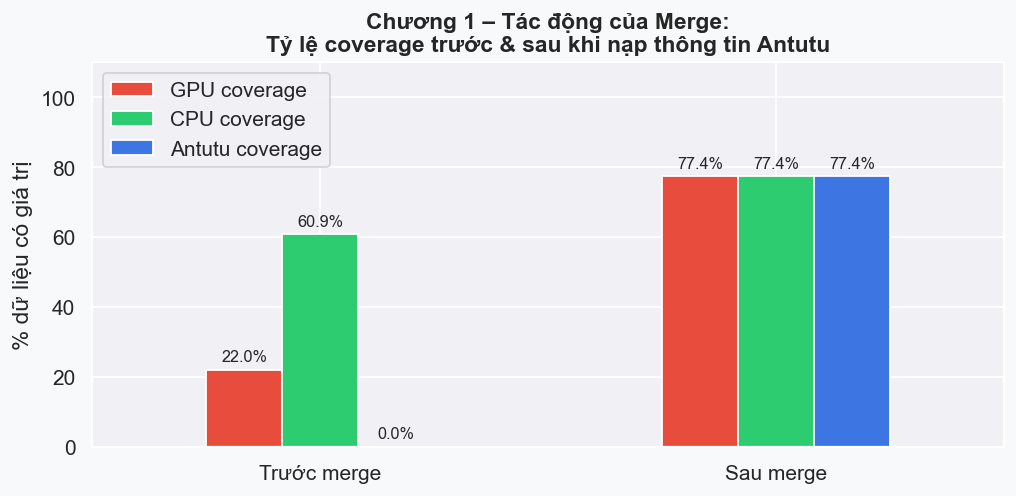

In [23]:

df_merged = cln.add_chipset_info(df_antutu, df_raw)

# Tính toán các chỉ số bao phủ (coverage) sau khi chạy hàm thực tế
gpu_fill_rate = df_merged["gpu"].notna().mean() * 100
match_rate    = df_merged["antutu_11"].notna().mean() * 100
arch_coverage = df_merged["architecture"].notna().mean() * 100

print(f"\n[Merge Result thực tế từ cln.add_chipset_info]")
print(f"  Số dòng sau merge    : {len(df_merged):,}")
print(f"  Match Antutu         : {df_merged['antutu_11'].notna().sum()}/{len(df_merged)} ({match_rate:.1f}%)")
print(f"  GPU_final coverage   : {gpu_fill_rate:.1f}%  (từ {(gpu_pre_fill):.1f}% lên {gpu_fill_rate:.1f}%)")

def plot_merge_impact(df_raw, df_merged, gpu_fill_rate, arch_coverage, match_rate):
    compare_df = pd.DataFrame({
        "Trước merge": {
            "GPU coverage": gpu_pre_fill,
            "CPU coverage": cpu_pre_fill,
            "Antutu coverage": 0.0,
        },
        "Sau merge": {
            "GPU coverage": gpu_fill_rate,
            "CPU coverage": arch_coverage,
            "Antutu coverage": match_rate,
        }
    })
    fig, ax = plt.subplots(figsize=(8, 4))
    compare_df.T.plot(kind="bar", ax=ax, color=["#E74C3C", "#2ECC71", "#3d75e3"], edgecolor="white", width=0.5)
    ax.set_title("Chương 1 – Tác động của Merge:\nTỷ lệ coverage trước & sau khi nạp thông tin Antutu", fontweight="bold")
    ax.set_ylabel("% dữ liệu có giá trị")
    ax.set_ylim(0, 110)
    ax.tick_params(axis="x", rotation=0)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=9)
    plt.tight_layout()
    plt.show()

plot_merge_impact(df_raw, df_merged, gpu_fill_rate, arch_coverage, match_rate)


Chỉ giữ lại những dòng có đủ dữ liệu về antutu-score

### CHƯƠNG 2: KHÁM PHÁ CẤU TRÚC DỮ LIỆU

Minh họa dữ liệu text thô

In [24]:
print("\n─── Ví dụ tên sản phẩm thô (chứa RAM/ROM trong Name) ───")
sample_names = df_merged["Name"].dropna().head(12).tolist()
for i, name in enumerate(sample_names, 1):
    print(f"  [{i:02d}] {name}")


─── Ví dụ tên sản phẩm thô (chứa RAM/ROM trong Name) ───
  [01] iPhone 17 Pro 256GB | Chính hãng
  [02] OPPO Find X9s 12GB 256GB
  [03] Samsung Galaxy S26 Ultra 12GB 256GB
  [04] iPhone 17 Pro Max 256GB | Chính hãng
  [05] Samsung Galaxy S26 12GB 256GB
  [06] iPhone 17 256GB | Chính hãng
  [07] Samsung Galaxy S25 Ultra 12GB 256GB
  [08] Điện thoại Itel P55 Plus NFC 8GB 256GB
  [09] Samsung Galaxy A17 5G 8GB 128GB
  [10] iPhone Air 256GB | Chính hãng
  [11] iPhone 15 128GB | Chính hãng VN/A
  [12] Điện thoại iPhone 16 Pro Max 256GB


In [25]:
df_merged["Name_clean"] = df_merged["Name"].apply(cln.clean_phone_name)

In [26]:
df_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 966 entries, 0 to 965
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed                966 non-null    int64  
 1    0                     966 non-null    int64  
 2   Name                   966 non-null    str    
 3   Link                   966 non-null    str    
 4   Kích thước màn hình    873 non-null    str    
 5   Công nghệ màn hình     814 non-null    str    
 6   Camera sau             855 non-null    str    
 7   Camera trước           823 non-null    str    
 8   Chipset                857 non-null    str    
 9   Công nghệ NFC          762 non-null    str    
 10  Bộ nhớ trong           915 non-null    str    
 11  Thẻ SIM                696 non-null    str    
 12  Hệ điều hành           762 non-null    str    
 13  Độ phân giải màn hình  659 non-null    str    
 14  Tính năng màn hình     732 non-null    str    
 15  Loại CPU         

2.4 Những sản phẩm không phải điện thoại

In [27]:
df_merged['Kích thước màn hình'] = df_merged['Kích thước màn hình'].apply(cln.clean_metrics)

mask_not_smartphone = (
    (df_merged['Kích thước màn hình'] < 4.0) |
    (df_merged['Name_clean'].str.lower().str.contains('tab|pad|win rt', na=False))
)

df_merged = df_merged[~mask_not_smartphone].reset_index(drop=True)
print(f'Có {mask_not_smartphone.sum()} sản phẩm không phải điện thoại, còn lại {len(df_merged)}')

Có 42 sản phẩm không phải điện thoại, còn lại 924


Tiến hành drop những dòng này

2.1 Áp dụng hàm Trích Xuất Thực Tế từ module `cln`

In [28]:
# df_merged["RAM_GB"]  = df_merged["Dung lượng RAM"].apply(cln.clean_metrics)
# df_merged["ROM_GB"]  = df_merged["Bộ nhớ trong"].apply(cln.clean_metrics)
# df_merged["Bat_mAh"] = df_merged["Pin"].apply(cln.clean_metrics)
# df_merged["Brand"]   = df_merged["Name"].apply(cln.get_brand)
# df_merged["Refresh Rate"] = df_merged.apply(lambda row: cln.extract_refresh_rate(row['Tần số quét'], row['Tính năng màn hình']),
#     axis=1)

# print("\n─── Kiểm tra kết quả trích xuất bằng hàm cln (10 dòng đầu) ───")
# check_cols = ["Name", "RAM_GB", "ROM_GB", "Bat_mAh", "Brand", "antutu_11", "Refresh Rate"]
# print(df_merged[check_cols].head(10).to_string(index=False))

Fill thêm hai cột Battery và Refresh Rate bằng dữ liệu từ GSMarena

2.2 Phát hiện "Dopplegangers" bằng hàm chuẩn hóa thực tế

In [29]:
dup_names = df_merged[df_merged.duplicated("Name_clean", keep=False)].sort_values("Name_clean")
print(f"\n  Số dòng có tên trùng (sau khi clean_phone_name): {len(dup_names)} / {len(df_merged)}")

sample_dup_name = (
    dup_names.groupby("Name_clean")
    .filter(lambda x: (x["Dung lượng RAM"].nunique() > 1) | (x["Bộ nhớ trong"].nunique() > 1))
    .groupby("Name_clean").head(3).head(9)
)
print("\n─── Ví dụ: Cùng tên sau clean, khác cấu hình RAM/ROM thực tế ───")
if not sample_dup_name.empty:
    print(sample_dup_name[["Name_clean", "Dung lượng RAM", "Bộ nhớ trong", "antutu_11"]].to_string(index=False))
else:
    print(dup_names[["Name_clean", "Dung lượng RAM", "Bộ nhớ trong"]].head(9).to_string(index=False))


  Số dòng có tên trùng (sau khi clean_phone_name): 360 / 924

─── Ví dụ: Cùng tên sau clean, khác cấu hình RAM/ROM thực tế ───
    Name_clean Dung lượng RAM Bộ nhớ trong  antutu_11
     honor 400          12 GB       512 GB  1020938.0
     honor 400          12 GB       256 GB  1020938.0
honor 600 lite          12 GB       256 GB        NaN
honor 600 lite           8 GB       256 GB        NaN
honor 600 lite           8 GB       256 GB        NaN
      honor 90           8 GB       256 GB   829085.0
      honor 90          12 GB       256 GB   829085.0
    honor x50i           6 GB       128 GB   419670.0
    honor x50i           8 GB       128 GB   527185.0


Vấn đề này sẽ được xử lý bằng cách gộp các dòng có cùng tên lại làm một và tạo thêm 4 biến mới thay cho 2 biến RAM và ROM